In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"C:\Users\rainc\Downloads\EncoderX\dataset\social_media_engagement_dataset.csv")

In [4]:
df.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


In [5]:
print("Rows:", df.shape[0])



Rows: 5000


In [6]:
print("Columns:", df.shape[1])


Columns: 20


In [7]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Post_ID', 'Timestamp', 'Platform', 'Content_Type', 'Category', 'Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Follower_Count', 'Engagement_Rate', 'Hour_of_Day', 'Day_of_Week', 'Hashtag_Count', 'Content_Length', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   str    
 1   Timestamp        5000 non-null   str    
 2   Platform         5000 non-null   str    
 3   Content_Type     5000 non-null   str    
 4   Category         5000 non-null   str    
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 10  Follower_Count   5000 non-null   int64  
 11  Engagement_Rate  5000 non-null   float64
 12  Hour_of_Day      5000 non-null   int64  
 13  Day_of_Week      5000 non-null   str    
 14  Hashtag_Count    5000 non-null   int64  
 15  Content_Length   5000 non-null   int64  
 16  Sentiment        5000 non-null   str    
 17  Influencer_Tier  5000 non

In [9]:
### Data Cleaning 

In [10]:
 ##Step 1: Check duplicates

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df.describe()

,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Hashtag_Count,Content_Length
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7536.838400,339.898800,835.233400,110968.397000,753.150600,249959.204000,11.960148,11.562600,14.755800,754.508400
std,10169.129568,399.813585,1013.769853,181287.350216,932.653475,144592.908235,71.462053,6.946577,8.666117,576.334039
min,18.000000,1.000000,2.000000,527.000000,5.000000,543.000000,0.050000,0.000000,0.000000,15.000000
25%,1707.750000,96.000000,177.000000,18506.750000,200.000000,124560.250000,1.030000,5.000000,7.000000,280.000000
50%,4073.500000,212.000000,427.500000,40663.500000,424.000000,248930.500000,2.300000,12.000000,15.000000,549.000000
75%,7783.000000,377.000000,1111.500000,84226.750000,805.000000,374697.500000,6.245000,18.000000,22.000000,1226.250000
max,49949.000000,1999.000000,4997.000000,999256.000000,4985.000000,499815.000000,3510.460000,23.000000,29.000000,1999.000000


In [13]:
## Step 2: Convert Timestamp

In [14]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [48]:
print(df["Timestamp"].dtype)

datetime64[us]


In [49]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5000, 20)


In [50]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Post_ID            0
Timestamp          0
Platform           0
Content_Type       0
Category           0
Likes              0
Comments           0
Shares             0
Views              0
Saves              0
Follower_Count     0
Engagement_Rate    0
Hour_of_Day        0
Day_of_Week        0
Hashtag_Count      0
Content_Length     0
Sentiment          0
Influencer_Tier    0
Has_Media          0
Is_Verified        0
dtype: int64


In [107]:
df = df.dropna()

print("Missing values after cleaning:", df.isnull().sum().sum())
print("Dataset shape:", df.shape)

Missing values after cleaning: 0
Dataset shape: (5000, 20)


In [108]:
text_columns = [
    "Platform",
    "Content_Type",
    "Category",
    "Day_of_Week",
    "Sentiment",
    "Influencer_Tier"
]

for col in text_columns:
    df[col] = df[col].str.strip()

# Check the categories after cleaning
for col in text_columns:
    print(f"\n{col}:")
    print(df[col].unique())


Platform:
<StringArray>
['Instagram', 'LinkedIn', 'Facebook', 'Twitter', 'YouTube', 'TikTok']
Length: 6, dtype: str

Content_Type:
<StringArray>
[      'Carousel',       'Document',          'Video',          'Photo',
           'Poll',         'Thread',           'Live',           'Reel',
           'Post',          'Story',          'Short',          'Tweet',
        'Retweet',        'Article',           'Duet',         'Stitch',
 'Community Post']
Length: 17, dtype: str

Category:
<StringArray>
[     'Business',        'Health',          'Food',        'Sports',
       'Fitness',     'Lifestyle',     'Education',        'Travel',
 'Entertainment',    'Technology',        'Gaming',       'Fashion']
Length: 12, dtype: str

Day_of_Week:
<StringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
Length: 7, dtype: str

Sentiment:
<StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str

Influencer_Tier:
<StringArray>
['Macro', 'Mid-tier'

In [109]:
df["Has_Media"] = df["Has_Media"].astype(bool)
df["Is_Verified"] = df["Is_Verified"].astype(bool)

print(df.dtypes)

Post_ID                       str
Timestamp          datetime64[us]
Platform                      str
Content_Type                  str
Category                      str
Likes                     float64
Comments                  float64
Shares                    float64
Views                     float64
Saves                     float64
Follower_Count              int64
Engagement_Rate           float64
Hour_of_Day                 int64
Day_of_Week                   str
Hashtag_Count               int64
Content_Length              int64
Sentiment                     str
Influencer_Tier               str
Has_Media                    bool
Is_Verified                  bool
dtype: object


In [15]:
numeric_columns = [
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Follower_Count",
    "Engagement_Rate",
    "Hashtag_Count",
    "Content_Length"
]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

Likes: 592 outliers
Comments: 564 outliers
Shares: 367 outliers
Views: 855 outliers
Saves: 658 outliers
Follower_Count: 0 outliers
Engagement_Rate: 609 outliers
Hashtag_Count: 0 outliers
Content_Length: 0 outliers


In [16]:
outlier_columns = [
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Engagement_Rate"
]

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers treated successfully.")

Outliers treated successfully.


In [17]:
print("Final dataset shape:", df.shape)

Final dataset shape: (5000, 20)


In [18]:
#Overall Statistics

In [19]:
## Exploratory Data Analysis (EDA)

In [20]:
print("Platform Distribution:")
print(df["Platform"].value_counts())

Platform Distribution:
Platform
Instagram    1283
Twitter       994
Facebook      984
TikTok        758
LinkedIn      502
YouTube       479
Name: count, dtype: int64


In [21]:
print("\nContent Type Distribution:")
print(df["Content_Type"].value_counts())



Content Type Distribution:
Content_Type
Video             616
Story             568
Poll              384
Post              378
Live              358
Carousel          333
Photo             320
Reel              306
Stitch            259
Retweet           251
Duet              248
Tweet             239
Thread            236
Community Post    135
Document          132
Short             121
Article           116
Name: count, dtype: int64


In [22]:
print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())


Sentiment Distribution:
Sentiment
Positive    2503
Neutral     1747
Negative     750
Name: count, dtype: int64


In [23]:
print("\nInfluencer Tier Distribution:")
print(df["Influencer_Tier"].value_counts())


Influencer Tier Distribution:
Influencer_Tier
Macro       3993
Mid-tier     483
Micro        427
Nano          97
Name: count, dtype: int64


In [24]:
# Average Engagement by Platform

In [25]:
platform_analysis = df.groupby("Platform")[[
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Engagement_Rate"
]].mean().sort_values("Engagement_Rate", ascending=False)

platform_analysis

,Likes,Comments,Shares,Views,Saves,Engagement_Rate
Platform,,,,,,
TikTok,14261.201187,652.396438,1893.610488,150935.851253,1281.169525,9.969670
YouTube,9727.449896,474.940501,981.989562,163417.031315,1404.535491,5.745532
Instagram,4943.328137,241.158223,150.958691,24898.541699,510.491037,3.689745
Facebook,4148.177846,197.399390,494.505081,40565.073171,399.166667,3.553122
Twitter,2419.637827,147.911469,1007.831992,49634.952716,253.938632,2.857218
LinkedIn,1035.368526,75.408367,256.615538,14834.960159,148.306773,1.337505


In [26]:
platform_analysis = df.groupby("Platform")[[
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Engagement_Rate"
]].mean().sort_values("Engagement_Rate", ascending=False)

platform_analysis

,Likes,Comments,Shares,Views,Saves,Engagement_Rate
Platform,,,,,,
TikTok,14261.201187,652.396438,1893.610488,150935.851253,1281.169525,9.969670
YouTube,9727.449896,474.940501,981.989562,163417.031315,1404.535491,5.745532
Instagram,4943.328137,241.158223,150.958691,24898.541699,510.491037,3.689745
Facebook,4148.177846,197.399390,494.505081,40565.073171,399.166667,3.553122
Twitter,2419.637827,147.911469,1007.831992,49634.952716,253.938632,2.857218
LinkedIn,1035.368526,75.408367,256.615538,14834.960159,148.306773,1.337505


In [27]:
content_analysis = df.groupby("Content_Type")[[
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Engagement_Rate"
]].mean().sort_values("Engagement_Rate", ascending=False)

content_analysis

,Likes,Comments,Shares,Views,Saves,Engagement_Rate
Content_Type,,,,,,
Duet,14124.023185,670.443548,1912.435484,150002.686492,1246.860887,10.163296
Stitch,14318.389479,651.299228,1837.991313,152539.045367,1341.656371,9.938494
Video,9204.606128,419.056818,1142.060065,104744.940747,917.923701,6.307403
Community Post,9672.063889,466.277778,1016.985185,161713.020370,1399.014815,5.335370
Short,9227.603306,434.578512,1015.049587,168632.857438,1444.144628,5.287211
Live,6099.710545,306.768156,674.877095,82376.475559,720.717877,4.517339
Carousel,5039.282282,240.312312,146.582583,25160.351351,519.933934,3.822830
Photo,4809.240625,243.381250,151.318750,24922.178125,477.621875,3.711859
Story,4599.797535,223.058099,297.797535,31922.281690,469.732394,3.606241


In [28]:
## Step 4: Data Visualization

In [29]:
## 1. Bar Chart — Average Engagement by Platform

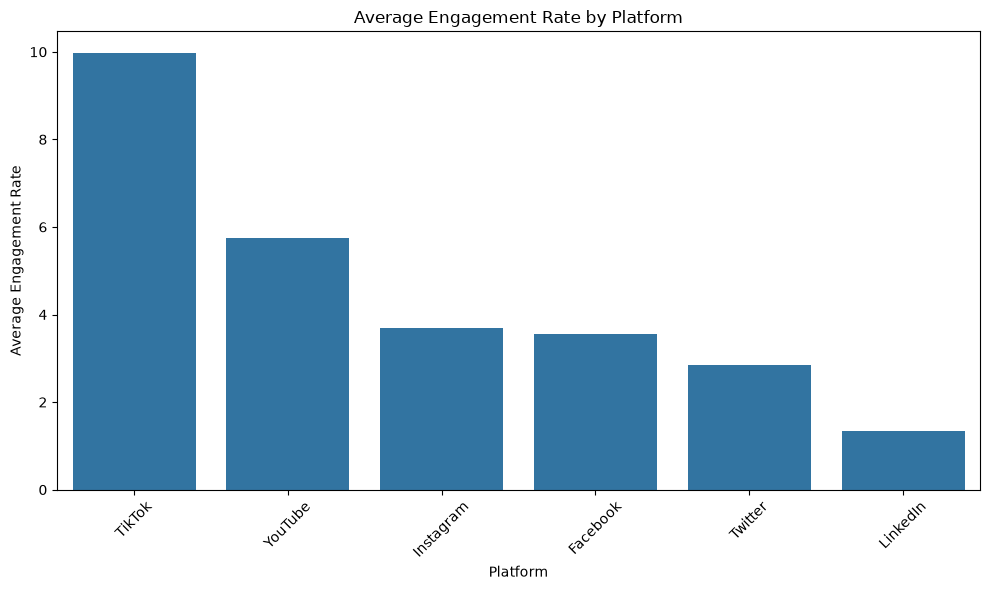

In [30]:
plt.figure(figsize=(10, 6))

platform_engagement = df.groupby("Platform")["Engagement_Rate"].mean().sort_values(ascending=False)

sns.barplot(
    x=platform_engagement.index,
    y=platform_engagement.values
)

plt.title("Average Engagement Rate by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Engagement Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## 2. Line Chart — Engagement by Hour

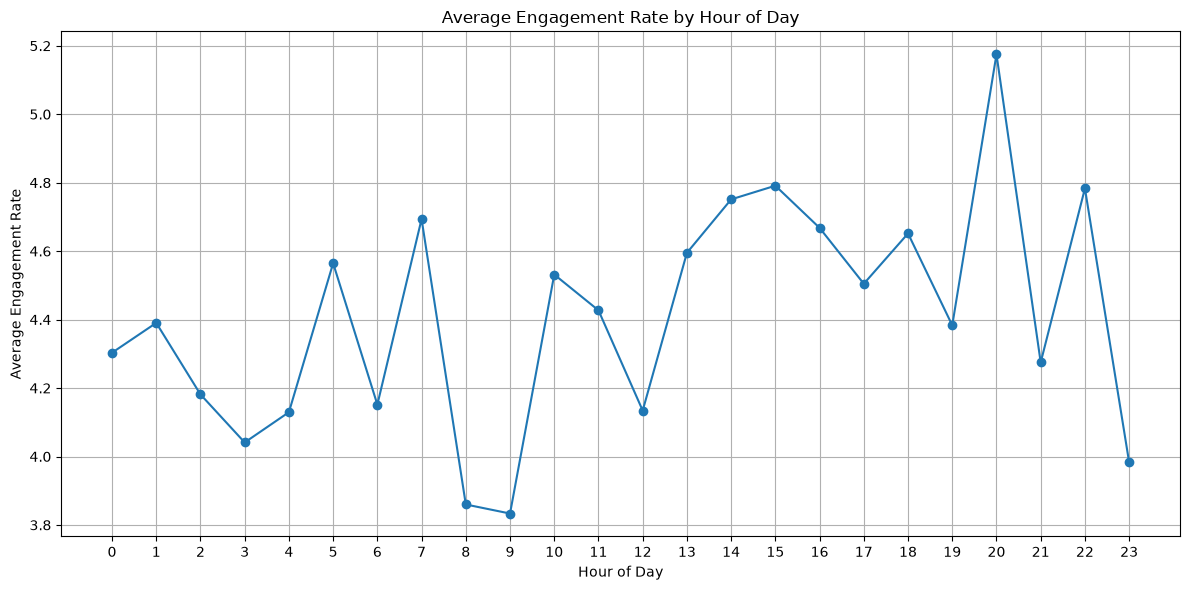

In [31]:
plt.figure(figsize=(12, 6))

hour_engagement = df.groupby("Hour_of_Day")["Engagement_Rate"].mean()

plt.plot(
    hour_engagement.index,
    hour_engagement.values,
    marker="o"
)

plt.title("Average Engagement Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Engagement Rate")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 3. Histogram — Distribution of Engagement Rate

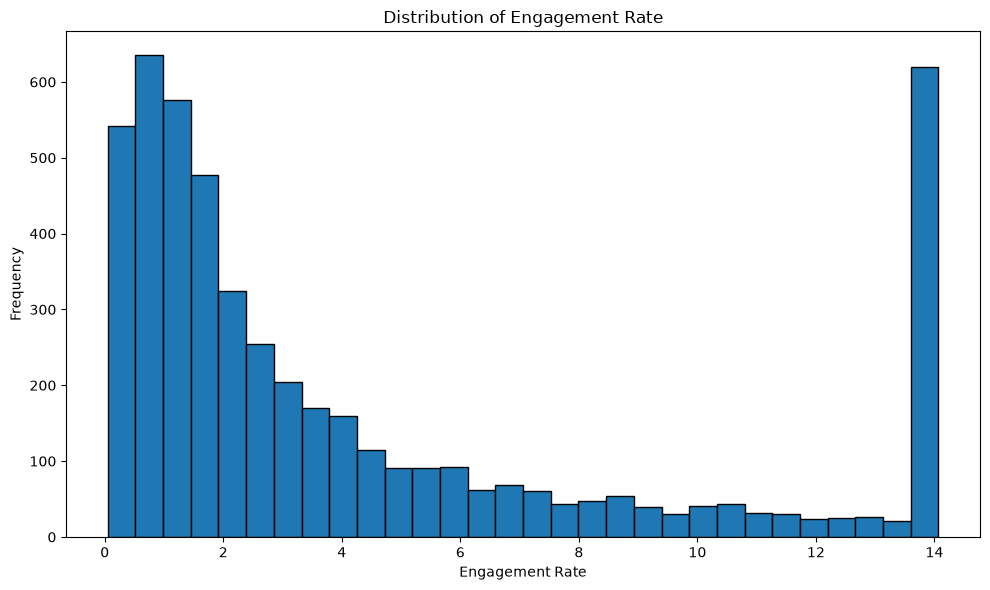

In [32]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Engagement_Rate"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
## 4. Correlation Heatmap — Feature Relationships

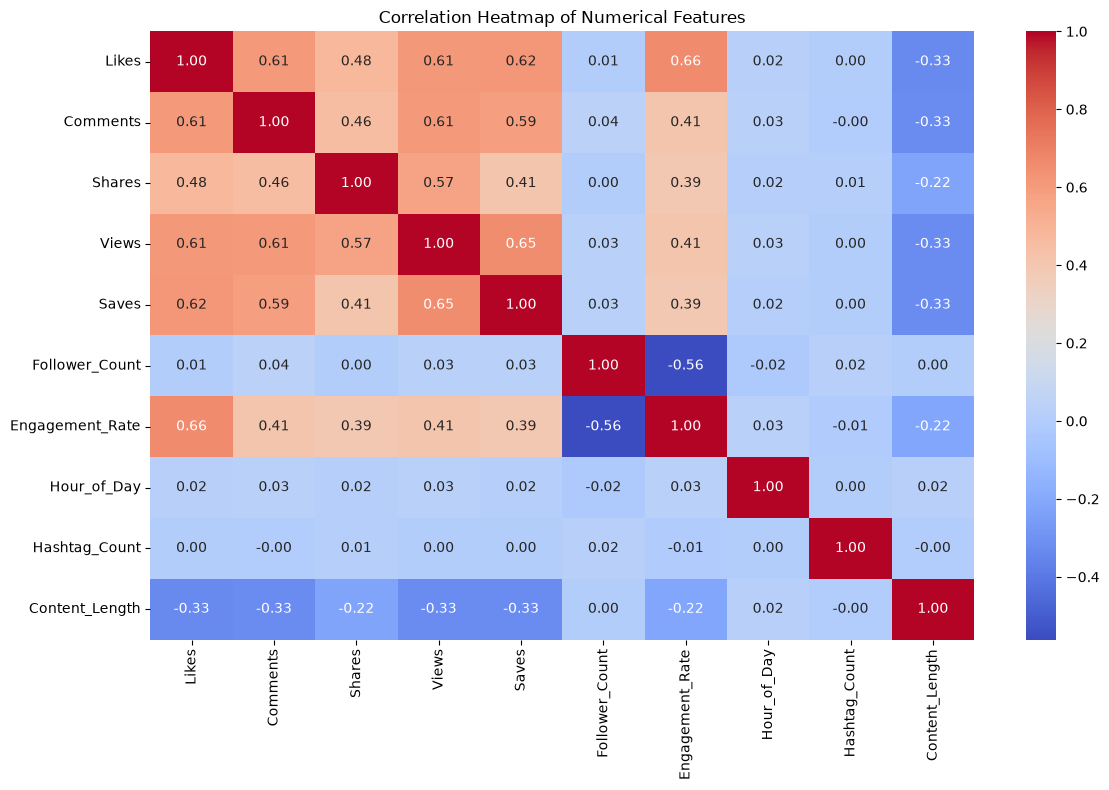

In [33]:
plt.figure(figsize=(12, 8))

numeric_columns = [
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Follower_Count",
    "Engagement_Rate",
    "Hour_of_Day",
    "Hashtag_Count",
    "Content_Length"
]

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
## 5. Scatter Plot — Views vs Engagement Rate

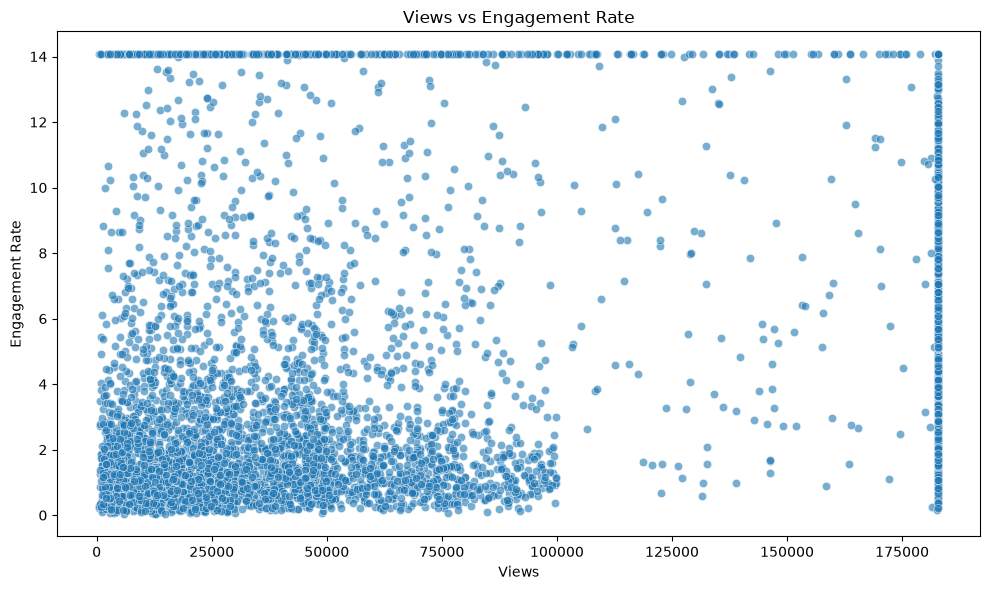

In [34]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Views",
    y="Engagement_Rate",
    alpha=0.6
)

plt.title("Views vs Engagement Rate")
plt.xlabel("Views")
plt.ylabel("Engagement Rate")
plt.tight_layout()
plt.show()